<a href="https://colab.research.google.com/github/shreyasd2006/Machine_Learning_Lab/blob/main/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (2240, 29)

Dataset columns:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Feature datatype classification:
ID                        : Nominal
Year_Birth                : Ratio
Education                 : Ordinal
Marital_Status            : Nominal
Income                    : Ratio
Kidhome                   : Ratio
Teenhome                  : Ratio
Dt_Customer               : Interval
Recency                   : Ratio
MntWines                  : Ratio
MntFruits                 : Ratio
MntMeatProducts           : Ratio
MntFishProducts           : Ratio
MntSweetProducts      

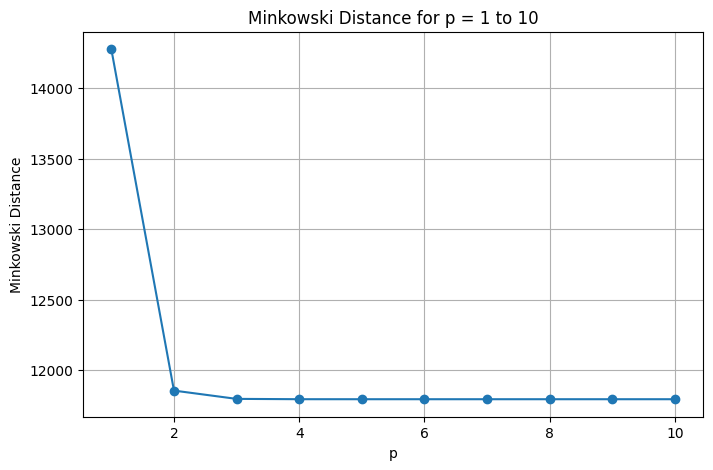


Comparison with SciPy:
p=1: Own=14277.000000, SciPy=14277.000000, Difference=0.0000000000
p=2: Own=11855.228425, SciPy=11855.228425, Difference=0.0000000000
p=3: Own=11796.426369, SciPy=11796.426369, Difference=0.0000000000
p=4: Own=11794.114274, SciPy=11794.114274, Difference=0.0000000000
p=5: Own=11794.005934, SciPy=11794.005934, Difference=0.0000000000
p=6: Own=11794.000329, SciPy=11794.000329, Difference=0.0000000000
p=7: Own=11794.000019, SciPy=11794.000019, Difference=0.0000000000
p=8: Own=11794.000001, SciPy=11794.000001, Difference=0.0000000000
p=9: Own=11794.000000, SciPy=11794.000000, Difference=0.0000000000
p=10: Own=11794.000000, SciPy=11794.000000, Difference=0.0000000000

Dot Product:
Own function : 2698271346.0
NumPy        : 2698271346.0

Vector A norm:
Own function : 58177.51401529632
NumPy        : 58177.51401529632

Vector B norm:
Own function : 46394.67637563603
NumPy        : 46394.67637563603

Mean vector:
[1.96880580e+03 2.46026786e+00 3.72991071e+00 5.22379754e

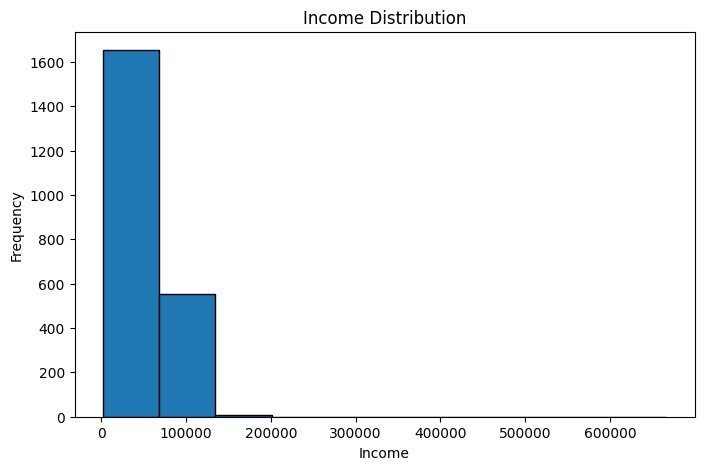


K-means cluster sizes:
Cluster 0: 810 points
Cluster 1: 204 points
Cluster 2: 1226 points


In [1]:
# ============================================================
# LAB 4 - A1
# Repeat Lab 03 experiments using GenAI
#
# GenAI Tool Used: ChatGPT
# Dataset: marketing_campaign
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski as scipy_minkowski


# ============================================================
# LOAD DATASET
# GenAI Tool Used: ChatGPT
# ============================================================

file_path = "Lab Session Data (1).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="marketing_campaign"
)

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())


# ============================================================
# LAB 03 - A1
# Identify datatype of each feature
# GenAI Tool Used: ChatGPT
# ============================================================

feature_types = {
    "ID": "Nominal",
    "Year_Birth": "Ratio",
    "Education": "Ordinal",
    "Marital_Status": "Nominal",
    "Income": "Ratio",
    "Kidhome": "Ratio",
    "Teenhome": "Ratio",
    "Dt_Customer": "Interval",
    "Recency": "Ratio",
    "MntWines": "Ratio",
    "MntFruits": "Ratio",
    "MntMeatProducts": "Ratio",
    "MntFishProducts": "Ratio",
    "MntSweetProducts": "Ratio",
    "MntGoldProds": "Ratio",
    "NumDealsPurchases": "Ratio",
    "NumWebPurchases": "Ratio",
    "NumCatalogPurchases": "Ratio",
    "NumStorePurchases": "Ratio",
    "NumWebVisitsMonth": "Ratio",
    "AcceptedCmp3": "Nominal",
    "AcceptedCmp4": "Nominal",
    "AcceptedCmp5": "Nominal",
    "AcceptedCmp1": "Nominal",
    "AcceptedCmp2": "Nominal",
    "Complain": "Nominal",
    "Z_CostContact": "Ratio",
    "Z_Revenue": "Ratio",
    "Response": "Nominal"
}

print("\nFeature datatype classification:")

for feature, datatype in feature_types.items():
    print(f"{feature:25s} : {datatype}")


# ============================================================
# LAB 03 - A2
# Label Encoding and One-Hot Encoding
# GenAI Tool Used: ChatGPT
# ============================================================

def label_encode(series, category_order=None):
    """
    Perform label encoding on a categorical feature.
    """

    if category_order is None:
        categories = sorted(
            series.dropna().astype(str).unique()
        )
    else:
        categories = category_order

    mapping = {
        category: index
        for index, category in enumerate(categories)
    }

    encoded = series.astype(str).map(mapping)

    return encoded, mapping


def one_hot_encode(dataframe, columns):
    """
    Perform one-hot encoding on selected categorical columns.
    """

    result = dataframe.copy()

    for column in columns:

        categories = sorted(
            result[column].dropna().astype(str).unique()
        )

        for category in categories:

            new_column = f"{column}_{category}"

            result[new_column] = (
                result[column].astype(str) == category
            ).astype(int)

        result.drop(columns=[column], inplace=True)

    return result


categorical_columns = [
    "Education",
    "Marital_Status"
]

education_order = [
    "Basic",
    "2n Cycle",
    "Graduation",
    "Master",
    "PhD"
]

education_encoded, education_mapping = label_encode(
    df["Education"],
    education_order
)

marital_encoded, marital_mapping = label_encode(
    df["Marital_Status"]
)

print("\nEducation mapping:")
print(education_mapping)

print("\nMarital Status mapping:")
print(marital_mapping)


# ============================================================
# LAB 03 - A3
# Convert categorical features
# GenAI Tool Used: ChatGPT
# ============================================================

label_encoded_df = df.copy()

label_encoded_df["Education"] = education_encoded
label_encoded_df["Marital_Status"] = marital_encoded

one_hot_df = one_hot_encode(
    df,
    categorical_columns
)

print("\nOriginal dimensions:")
print(df.shape)

print("\nLabel encoded dimensions:")
print(label_encoded_df.shape)

print("\nOne-hot encoded dimensions:")
print(one_hot_df.shape)


# ============================================================
# PREPARE NUMERICAL DATA
# GenAI Tool Used: ChatGPT
# ============================================================

analysis_df = df.copy()

# Convert date into number of days from earliest customer date
analysis_df["Dt_Customer"] = pd.to_datetime(
    analysis_df["Dt_Customer"],
    dayfirst=True
)

analysis_df["Dt_Customer"] = (
    analysis_df["Dt_Customer"]
    - analysis_df["Dt_Customer"].min()
).dt.days

# Encode categorical columns
analysis_df["Education"], _ = label_encode(
    analysis_df["Education"],
    education_order
)

analysis_df["Marital_Status"], _ = label_encode(
    analysis_df["Marital_Status"]
)

# Fill missing income values
analysis_df["Income"] = analysis_df["Income"].fillna(
    analysis_df["Income"].median()
)

# Remove ID and constant columns
analysis_df.drop(
    columns=[
        "ID",
        "Z_CostContact",
        "Z_Revenue"
    ],
    inplace=True
)

numeric_data = analysis_df.to_numpy(
    dtype=float
)


# ============================================================
# LAB 03 - A4
# Generalized Minkowski Distance
# GenAI Tool Used: ChatGPT
# ============================================================

def minkowski_distance(vector_a, vector_b, p):
    """
    Calculate generalized Minkowski distance.

    p = 1 -> Manhattan distance
    p = 2 -> Euclidean distance
    """

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )

    if vector_a.shape != vector_b.shape:
        raise ValueError(
            "Vectors must have the same dimensions."
        )

    if p <= 0:
        raise ValueError(
            "p must be greater than zero."
        )

    return np.sum(
        np.abs(vector_a - vector_b) ** p
    ) ** (1 / p)


# ============================================================
# LAB 03 - A5
# Minkowski distance for p = 1 to 10
# GenAI Tool Used: ChatGPT
# ============================================================

vector_a = numeric_data[0]
vector_b = numeric_data[1]

p_values = list(range(1, 11))
distances = []

for p in p_values:

    distance = minkowski_distance(
        vector_a,
        vector_b,
        p
    )

    distances.append(distance)

    print(
        f"p = {p:2d}, "
        f"Distance = {distance:.4f}"
    )


plt.figure(figsize=(8, 5))

plt.plot(
    p_values,
    distances,
    marker="o"
)

plt.xlabel("p")
plt.ylabel("Minkowski Distance")
plt.title("Minkowski Distance for p = 1 to 10")
plt.grid(True)

plt.show()


# ============================================================
# LAB 03 - A6
# Compare own function with SciPy
# GenAI Tool Used: ChatGPT
# ============================================================

print("\nComparison with SciPy:")

for p in range(1, 11):

    own_distance = minkowski_distance(
        vector_a,
        vector_b,
        p
    )

    scipy_distance = scipy_minkowski(
        vector_a,
        vector_b,
        p=p
    )

    print(
        f"p={p}: "
        f"Own={own_distance:.6f}, "
        f"SciPy={scipy_distance:.6f}, "
        f"Difference={abs(own_distance-scipy_distance):.10f}"
    )


# ============================================================
# LAB 03 - A7
# Dot Product and Euclidean Norm
# GenAI Tool Used: ChatGPT
# ============================================================

def dot_product(vector_a, vector_b):
    """
    Calculate dot product of two vectors.
    """

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )

    return np.sum(
        vector_a * vector_b
    )


def euclidean_norm(vector):
    """
    Calculate Euclidean norm of a vector.
    """

    vector = np.asarray(
        vector,
        dtype=float
    )

    return np.sqrt(
        np.sum(vector ** 2)
    )


own_dot = dot_product(
    vector_a,
    vector_b
)

numpy_dot = np.dot(
    vector_a,
    vector_b
)

own_norm_a = euclidean_norm(
    vector_a
)

numpy_norm_a = np.linalg.norm(
    vector_a
)

own_norm_b = euclidean_norm(
    vector_b
)

numpy_norm_b = np.linalg.norm(
    vector_b
)

print("\nDot Product:")
print("Own function :", own_dot)
print("NumPy        :", numpy_dot)

print("\nVector A norm:")
print("Own function :", own_norm_a)
print("NumPy        :", numpy_norm_a)

print("\nVector B norm:")
print("Own function :", own_norm_b)
print("NumPy        :", numpy_norm_b)


# ============================================================
# LAB 03 - A8
# Mean, Variance and Standard Deviation
# GenAI Tool Used: ChatGPT
# ============================================================

def calculate_mean(data, axis=None):
    """
    Calculate mean of data.
    """

    data = np.asarray(
        data,
        dtype=float
    )

    return np.mean(
        data,
        axis=axis
    )


def calculate_variance(data, axis=None):
    """
    Calculate population variance.
    """

    data = np.asarray(
        data,
        dtype=float
    )

    mean = np.mean(
        data,
        axis=axis,
        keepdims=True
    )

    return np.mean(
        (data - mean) ** 2,
        axis=axis
    )


def calculate_standard_deviation(
    data,
    axis=None
):
    """
    Calculate population standard deviation.
    """

    return np.sqrt(
        calculate_variance(
            data,
            axis
        )
    )


mean_vector = calculate_mean(
    numeric_data,
    axis=0
)

variance_vector = calculate_variance(
    numeric_data,
    axis=0
)

std_vector = calculate_standard_deviation(
    numeric_data,
    axis=0
)

print("\nMean vector:")
print(mean_vector)

print("\nVariance vector:")
print(variance_vector)

print("\nStandard deviation vector:")
print(std_vector)


# ============================================================
# LAB 03 - A9
# Compare with NumPy
# GenAI Tool Used: ChatGPT
# ============================================================

numpy_mean = np.mean(
    numeric_data,
    axis=0
)

numpy_variance = np.var(
    numeric_data,
    axis=0
)

numpy_std = np.std(
    numeric_data,
    axis=0
)

print("\nMaximum mean difference:",
      np.max(np.abs(
          mean_vector - numpy_mean
      )))

print("Maximum variance difference:",
      np.max(np.abs(
          variance_vector - numpy_variance
      )))

print("Maximum standard deviation difference:",
      np.max(np.abs(
          std_vector - numpy_std
      )))


# ============================================================
# LAB 03 - A10
# Histogram of a feature
# GenAI Tool Used: ChatGPT
# ============================================================

income = df["Income"].dropna()

income_mean = calculate_mean(
    income
)

income_variance = calculate_variance(
    income
)

print("\nIncome Mean:", income_mean)
print("Income Variance:", income_variance)

plt.figure(figsize=(8, 5))

plt.hist(
    income,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")

plt.show()


# ============================================================
# LAB 03 - A11
# K-Means Algorithm
# GenAI Tool Used: ChatGPT
# ============================================================

def initialize_centroids(
    data,
    k,
    random_state=42
):
    """
    Randomly select k initial centroids.
    """

    rng = np.random.default_rng(
        random_state
    )

    indices = rng.choice(
        len(data),
        size=k,
        replace=False
    )

    return data[indices].copy()


def assign_clusters(
    data,
    centroids
):
    """
    Assign each data point to nearest centroid.
    """

    distances = np.sqrt(
        np.sum(
            (
                data[:, np.newaxis, :]
                -
                centroids[np.newaxis, :, :]
            ) ** 2,
            axis=2
        )
    )

    return np.argmin(
        distances,
        axis=1
    )


def update_centroids(
    data,
    labels,
    centroids
):
    """
    Recalculate cluster centroids.
    """

    new_centroids = []

    for cluster in range(
        len(centroids)
    ):

        cluster_points = data[
            labels == cluster
        ]

        if len(cluster_points) == 0:
            new_centroids.append(
                centroids[cluster]
            )
        else:
            new_centroids.append(
                np.mean(
                    cluster_points,
                    axis=0
                )
            )

    return np.array(
        new_centroids
    )


def kmeans(
    data,
    k,
    max_iterations=100,
    tolerance=1e-6,
    random_state=42
):
    """
    Implement the basic K-means algorithm.
    """

    centroids = initialize_centroids(
        data,
        k,
        random_state
    )

    for iteration in range(
        max_iterations
    ):

        labels = assign_clusters(
            data,
            centroids
        )

        new_centroids = update_centroids(
            data,
            labels,
            centroids
        )

        shift = np.linalg.norm(
            new_centroids - centroids
        )

        centroids = new_centroids

        if shift < tolerance:
            break

    return labels, centroids


# Standardize data before K-means
# GenAI Tool Used: ChatGPT

data_mean = np.mean(
    numeric_data,
    axis=0
)

data_std = np.std(
    numeric_data,
    axis=0
)

data_std[data_std == 0] = 1

standardized_data = (
    numeric_data - data_mean
) / data_std


labels, centroids = kmeans(
    standardized_data,
    k=3
)

print("\nK-means cluster sizes:")

for cluster in range(3):

    print(
        f"Cluster {cluster}:",
        np.sum(labels == cluster),
        "points"
    )

In [2]:
# ============================================================
# LAB 04 - A2
# Generate Unit Test Cases using AI Tools
#
# GenAI Tool Used: ChatGPT
# Tests functions developed in Lab 03 / Lab 04 A1
# ============================================================

import unittest
import numpy as np
import pandas as pd


# ============================================================
# TEST LABEL ENCODING
# GenAI Tool Used: ChatGPT
# ============================================================

class TestLabelEncoding(unittest.TestCase):

    def test_basic_label_encoding(self):

        data = pd.Series(
            ["Red", "Blue", "Red", "Green"]
        )

        encoded, mapping = label_encode(
            data
        )

        self.assertEqual(
            len(encoded),
            4
        )

        self.assertEqual(
            len(mapping),
            3
        )

        self.assertEqual(
            encoded.iloc[0],
            encoded.iloc[2]
        )


# ============================================================
# TEST ONE-HOT ENCODING
# GenAI Tool Used: ChatGPT
# ============================================================

class TestOneHotEncoding(unittest.TestCase):

    def test_one_hot_encoding(self):

        data = pd.DataFrame({
            "Color": [
                "Red",
                "Blue",
                "Red"
            ]
        })

        result = one_hot_encode(
            data,
            ["Color"]
        )

        self.assertEqual(
            result.shape,
            (3, 2)
        )

        self.assertEqual(
            result["Color_Red"].tolist(),
            [1, 0, 1]
        )


# ============================================================
# TEST MINKOWSKI DISTANCE
# GenAI Tool Used: ChatGPT
# ============================================================

class TestMinkowskiDistance(unittest.TestCase):

    def test_manhattan_distance(self):

        a = np.array([1, 2, 3])
        b = np.array([4, 6, 3])

        result = minkowski_distance(
            a,
            b,
            1
        )

        self.assertAlmostEqual(
            result,
            7.0
        )

    def test_euclidean_distance(self):

        a = np.array([1, 2, 3])
        b = np.array([4, 6, 3])

        result = minkowski_distance(
            a,
            b,
            2
        )

        self.assertAlmostEqual(
            result,
            5.0
        )

    def test_same_vector(self):

        a = np.array([1, 2, 3])

        result = minkowski_distance(
            a,
            a,
            2
        )

        self.assertEqual(
            result,
            0
        )


# ============================================================
# TEST VECTOR OPERATIONS
# GenAI Tool Used: ChatGPT
# ============================================================

class TestVectorOperations(unittest.TestCase):

    def test_dot_product(self):

        a = np.array([1, 2, 3])
        b = np.array([4, 5, 6])

        result = dot_product(
            a,
            b
        )

        self.assertEqual(
            result,
            32
        )

    def test_euclidean_norm(self):

        a = np.array([3, 4])

        result = euclidean_norm(
            a
        )

        self.assertAlmostEqual(
            result,
            5.0
        )


# ============================================================
# TEST STATISTICAL FUNCTIONS
# GenAI Tool Used: ChatGPT
# ============================================================

class TestStatistics(unittest.TestCase):

    def setUp(self):

        self.data = np.array([
            1, 2, 3, 4, 5
        ])

    def test_mean(self):

        result = calculate_mean(
            self.data
        )

        self.assertAlmostEqual(
            result,
            3.0
        )

    def test_variance(self):

        result = calculate_variance(
            self.data
        )

        self.assertAlmostEqual(
            result,
            2.0
        )

    def test_standard_deviation(self):

        result = calculate_standard_deviation(
            self.data
        )

        self.assertAlmostEqual(
            result,
            np.sqrt(2)
        )


# ============================================================
# TEST K-MEANS
# GenAI Tool Used: ChatGPT
# ============================================================

class TestKMeans(unittest.TestCase):

    def setUp(self):

        self.data = np.array([
            [1, 1],
            [1, 2],
            [2, 1],
            [8, 8],
            [8, 9],
            [9, 8]
        ], dtype=float)

    def test_number_of_labels(self):

        labels, centroids = kmeans(
            self.data,
            k=2,
            random_state=42
        )

        self.assertEqual(
            len(labels),
            len(self.data)
        )

    def test_number_of_centroids(self):

        labels, centroids = kmeans(
            self.data,
            k=2,
            random_state=42
        )

        self.assertEqual(
            len(centroids),
            2
        )

    def test_number_of_clusters(self):

        labels, centroids = kmeans(
            self.data,
            k=2,
            random_state=42
        )

        self.assertEqual(
            len(np.unique(labels)),
            2
        )


# ============================================================
# RUN ALL UNIT TESTS
# ============================================================

test_suite = unittest.TestSuite()

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestLabelEncoding
    )
)

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestOneHotEncoding
    )
)

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestMinkowskiDistance
    )
)

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestVectorOperations
    )
)

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestStatistics
    )
)

test_suite.addTest(
    unittest.defaultTestLoader.loadTestsFromTestCase(
        TestKMeans
    )
)

runner = unittest.TextTestRunner(
    verbosity=2
)

runner.run(test_suite)

test_basic_label_encoding (__main__.TestLabelEncoding.test_basic_label_encoding) ... ok
test_one_hot_encoding (__main__.TestOneHotEncoding.test_one_hot_encoding) ... ok
test_euclidean_distance (__main__.TestMinkowskiDistance.test_euclidean_distance) ... ok
test_manhattan_distance (__main__.TestMinkowskiDistance.test_manhattan_distance) ... ok
test_same_vector (__main__.TestMinkowskiDistance.test_same_vector) ... ok
test_dot_product (__main__.TestVectorOperations.test_dot_product) ... ok
test_euclidean_norm (__main__.TestVectorOperations.test_euclidean_norm) ... ok
test_mean (__main__.TestStatistics.test_mean) ... ok
test_standard_deviation (__main__.TestStatistics.test_standard_deviation) ... ok
test_variance (__main__.TestStatistics.test_variance) ... ok
test_number_of_centroids (__main__.TestKMeans.test_number_of_centroids) ... ok
test_number_of_clusters (__main__.TestKMeans.test_number_of_clusters) ... ok
test_number_of_labels (__main__.TestKMeans.test_number_of_labels) ... ok

----

<unittest.runner.TextTestResult run=13 errors=0 failures=0>

In [3]:
# ============================================================
# LAB 04 - A3
# Performance Comparison of Two K-Means Algorithms
#
# Version 1: Self-developed K-means from Lab 03
# Version 2: AI-developed K-means
#
# GenAI Tool Used: ChatGPT
# Dataset: marketing_campaign
# ============================================================

import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans


# ============================================================
# PREPARE DATA
# GenAI Tool Used: ChatGPT
# ============================================================

# Use the numerical data prepared in A1.
# Standardization ensures that features with large numerical
# ranges do not dominate the distance calculation.

data_mean = np.mean(
    numeric_data,
    axis=0
)

data_std = np.std(
    numeric_data,
    axis=0
)

data_std[data_std == 0] = 1

standardized_data = (
    numeric_data - data_mean
) / data_std


# ============================================================
# VERSION 1
# SELF-DEVELOPED K-MEANS
# GenAI Tool Used: ChatGPT
# ============================================================

def calculate_inertia(
    data,
    labels,
    centroids
):
    """
    Calculate within-cluster sum of squared distances.
    """

    inertia = 0.0

    for cluster in range(
        len(centroids)
    ):

        cluster_points = data[
            labels == cluster
        ]

        if len(cluster_points) > 0:

            inertia += np.sum(
                (
                    cluster_points
                    -
                    centroids[cluster]
                ) ** 2
            )

    return inertia


start_time_self = time.perf_counter()

self_labels, self_centroids = kmeans(
    standardized_data,
    k=3,
    max_iterations=100,
    tolerance=1e-6,
    random_state=42
)

end_time_self = time.perf_counter()

self_execution_time = (
    end_time_self
    -
    start_time_self
)

self_inertia = calculate_inertia(
    standardized_data,
    self_labels,
    self_centroids
)


# ============================================================
# VERSION 2
# AI-DEVELOPED K-MEANS
# GenAI Tool Used: ChatGPT
# ============================================================

start_time_ai = time.perf_counter()

ai_kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=100,
    random_state=42
)

ai_labels = ai_kmeans.fit_predict(
    standardized_data
)

end_time_ai = time.perf_counter()

ai_execution_time = (
    end_time_ai
    -
    start_time_ai
)

ai_inertia = ai_kmeans.inertia_


# ============================================================
# PERFORMANCE COMPARISON
# GenAI Tool Used: ChatGPT
# ============================================================

comparison = pd.DataFrame({

    "Algorithm": [
        "Self-developed K-means",
        "AI-developed K-means"
    ],

    "Execution Time (seconds)": [
        self_execution_time,
        ai_execution_time
    ],

    "Inertia": [
        self_inertia,
        ai_inertia
    ],

    "Iterations": [
        "-",
        ai_kmeans.n_iter_
    ]
})

print(
    "\n========== K-MEANS PERFORMANCE COMPARISON =========="
)

print(comparison.to_string(index=False))


# ============================================================
# DETERMINE FASTER ALGORITHM
# GenAI Tool Used: ChatGPT
# ============================================================

if self_execution_time < ai_execution_time:

    faster_algorithm = (
        "Self-developed K-means"
    )

else:

    faster_algorithm = (
        "AI-developed K-means"
    )


print(
    "\nFaster algorithm:",
    faster_algorithm
)


# ============================================================
# COMPARE INERTIA
# GenAI Tool Used: ChatGPT
# ============================================================

if self_inertia < ai_inertia:

    better_inertia = (
        "Self-developed K-means"
    )

elif ai_inertia < self_inertia:

    better_inertia = (
        "AI-developed K-means"
    )

else:

    better_inertia = "Both are equal"


print(
    "Lower inertia:",
    better_inertia
)


# ============================================================
# CLUSTER SIZE COMPARISON
# GenAI Tool Used: ChatGPT
# ============================================================

self_cluster_sizes = np.bincount(
    self_labels,
    minlength=3
)

ai_cluster_sizes = np.bincount(
    ai_labels,
    minlength=3
)

cluster_sizes = pd.DataFrame({

    "Cluster": [
        0, 1, 2
    ],

    "Self-developed K-means": [
        self_cluster_sizes[0],
        self_cluster_sizes[1],
        self_cluster_sizes[2]
    ],

    "AI-developed K-means": [
        ai_cluster_sizes[0],
        ai_cluster_sizes[1],
        ai_cluster_sizes[2]
    ]
})

print(
    "\n========== CLUSTER SIZE COMPARISON =========="
)

print(
    cluster_sizes.to_string(index=False)
)


========== K-MEANS PERFORMANCE COMPARISON ==========
             Algorithm  Execution Time (seconds)      Inertia Iterations
Self-developed K-means                  0.021477 43629.173683          -
  AI-developed K-means                  0.062837 43197.773975          8

Faster algorithm: Self-developed K-means
Lower inertia: AI-developed K-means

========== CLUSTER SIZE COMPARISON ==========
 Cluster  Self-developed K-means  AI-developed K-means
       0                     810                  1055
       1                     204                   550
       2                    1226                   635
